In [ ]:
!nvidia-smi

Sat Sep 19 10:31:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 9.0 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import ultralytics

print("Ultralytics version:", ultralytics.__version__)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics version: 8.4.155


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="fEGzJhNTAwBpIx5jFCpb")
project = rf.workspace("rebar-exposure-and-spalling").project("rebar-exposure-qm02o")
version = project.version(4)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 7.0 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.2
    Uninstalling typer-0.27.2:
      Successfully uninstalled typer-0.27.2
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Rebar-exposure-4 in yolov8:: 100%|██████████| 3439/3439 [00:00<00:00, 6899.22it/s]


In [ ]:
!find /content/Rebar-exposure-4 -maxdepth 2 -type f | head -30

/content/Rebar-exposure-4/README.dataset.txt
/content/Rebar-exposure-4/data.yaml
/content/Rebar-exposure-4/README.roboflow.txt


In [ ]:
!cat /content/Rebar-exposure-4/data.yaml

names:
- Exposed rebar
nc: 1
roboflow:
  license: CC BY 4.0
  project: rebar-exposure-qm02o
  url: https://universe.roboflow.com/rebar-exposure-and-spalling/rebar-exposure-qm02o/dataset/4
  version: 4
  workspace: rebar-exposure-and-spalling
test: ../test/images
train: ../train/images
val: ../valid/images


In [ ]:
!echo "Train images:" $(find /content/Rebar-exposure-4/train/images -type f | wc -l)
!echo "Train labels:" $(find /content/Rebar-exposure-4/train/labels -type f | wc -l)
!echo "Valid images:" $(find /content/Rebar-exposure-4/valid/images -type f | wc -l)
!echo "Valid labels:" $(find /content/Rebar-exposure-4/valid/labels -type f | wc -l)

Train images: 1547
Train labels: 1547
Valid images: 168
Valid labels: 168


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")

results = model.train(
    data="/content/Rebar-exposure-4/data.yaml",
    epochs=5,
    imgsz=640,
    batch=8,
    device=0,
    project="/content/runs",
    name="exposed_rebar_verification",
    seed=42
)

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Rebar-exposure-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exposed_rebar_verification, nbs=64, nm

In [ ]:
!find /content/runs/exposed_rebar_verification -maxdepth 1 -type f | sort

/content/runs/exposed_rebar_verification/args.yaml
/content/runs/exposed_rebar_verification/BoxF1_curve.png
/content/runs/exposed_rebar_verification/BoxP_curve.png
/content/runs/exposed_rebar_verification/BoxPR_curve.png
/content/runs/exposed_rebar_verification/BoxR_curve.png
/content/runs/exposed_rebar_verification/confusion_matrix_normalized.png
/content/runs/exposed_rebar_verification/confusion_matrix.png
/content/runs/exposed_rebar_verification/labels.jpg
/content/runs/exposed_rebar_verification/MaskF1_curve.png
/content/runs/exposed_rebar_verification/MaskP_curve.png
/content/runs/exposed_rebar_verification/MaskPR_curve.png
/content/runs/exposed_rebar_verification/MaskR_curve.png
/content/runs/exposed_rebar_verification/results.csv
/content/runs/exposed_rebar_verification/results.png
/content/runs/exposed_rebar_verification/train_batch0.jpg
/content/runs/exposed_rebar_verification/train_batch1.jpg
/content/runs/exposed_rebar_verification/train_batch2.jpg
/content/runs/exposed_reba

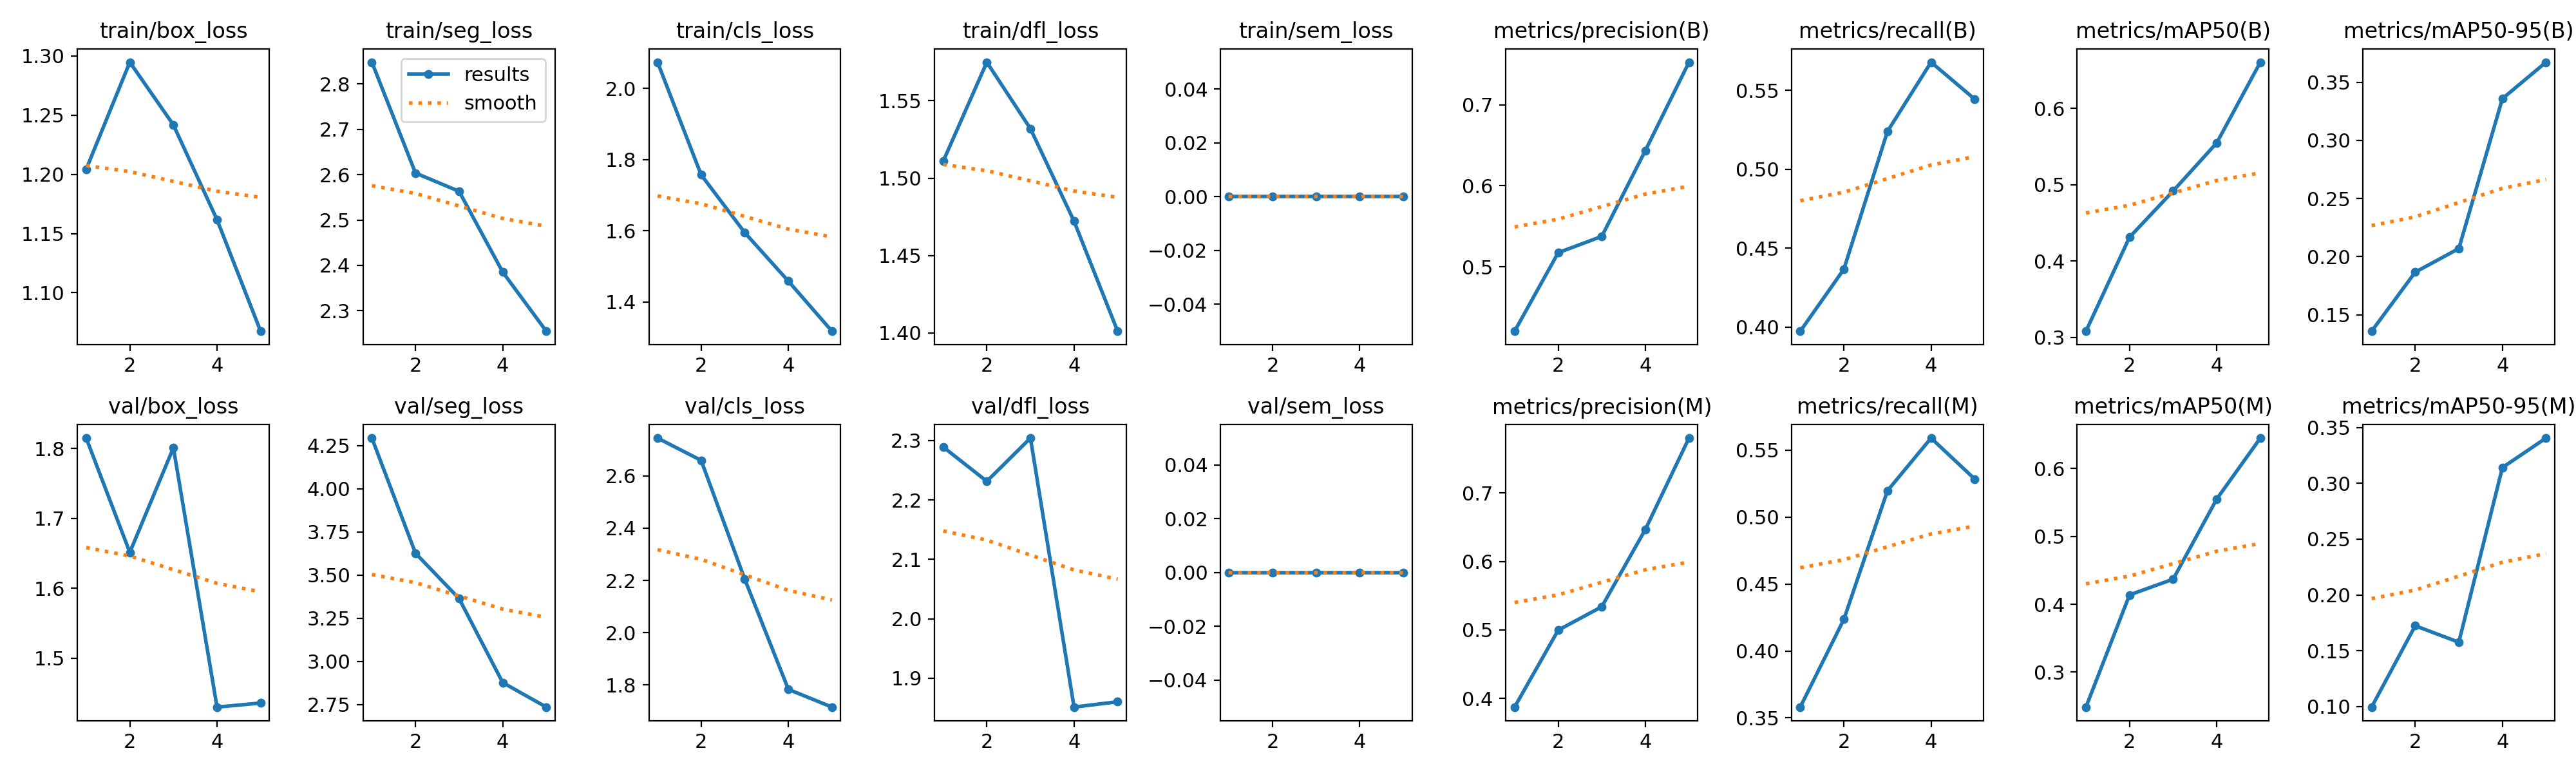

In [ ]:
from IPython.display import Image, display

display(Image(filename="/content/runs/exposed_rebar_verification/results.png"))

Ground-truth labels


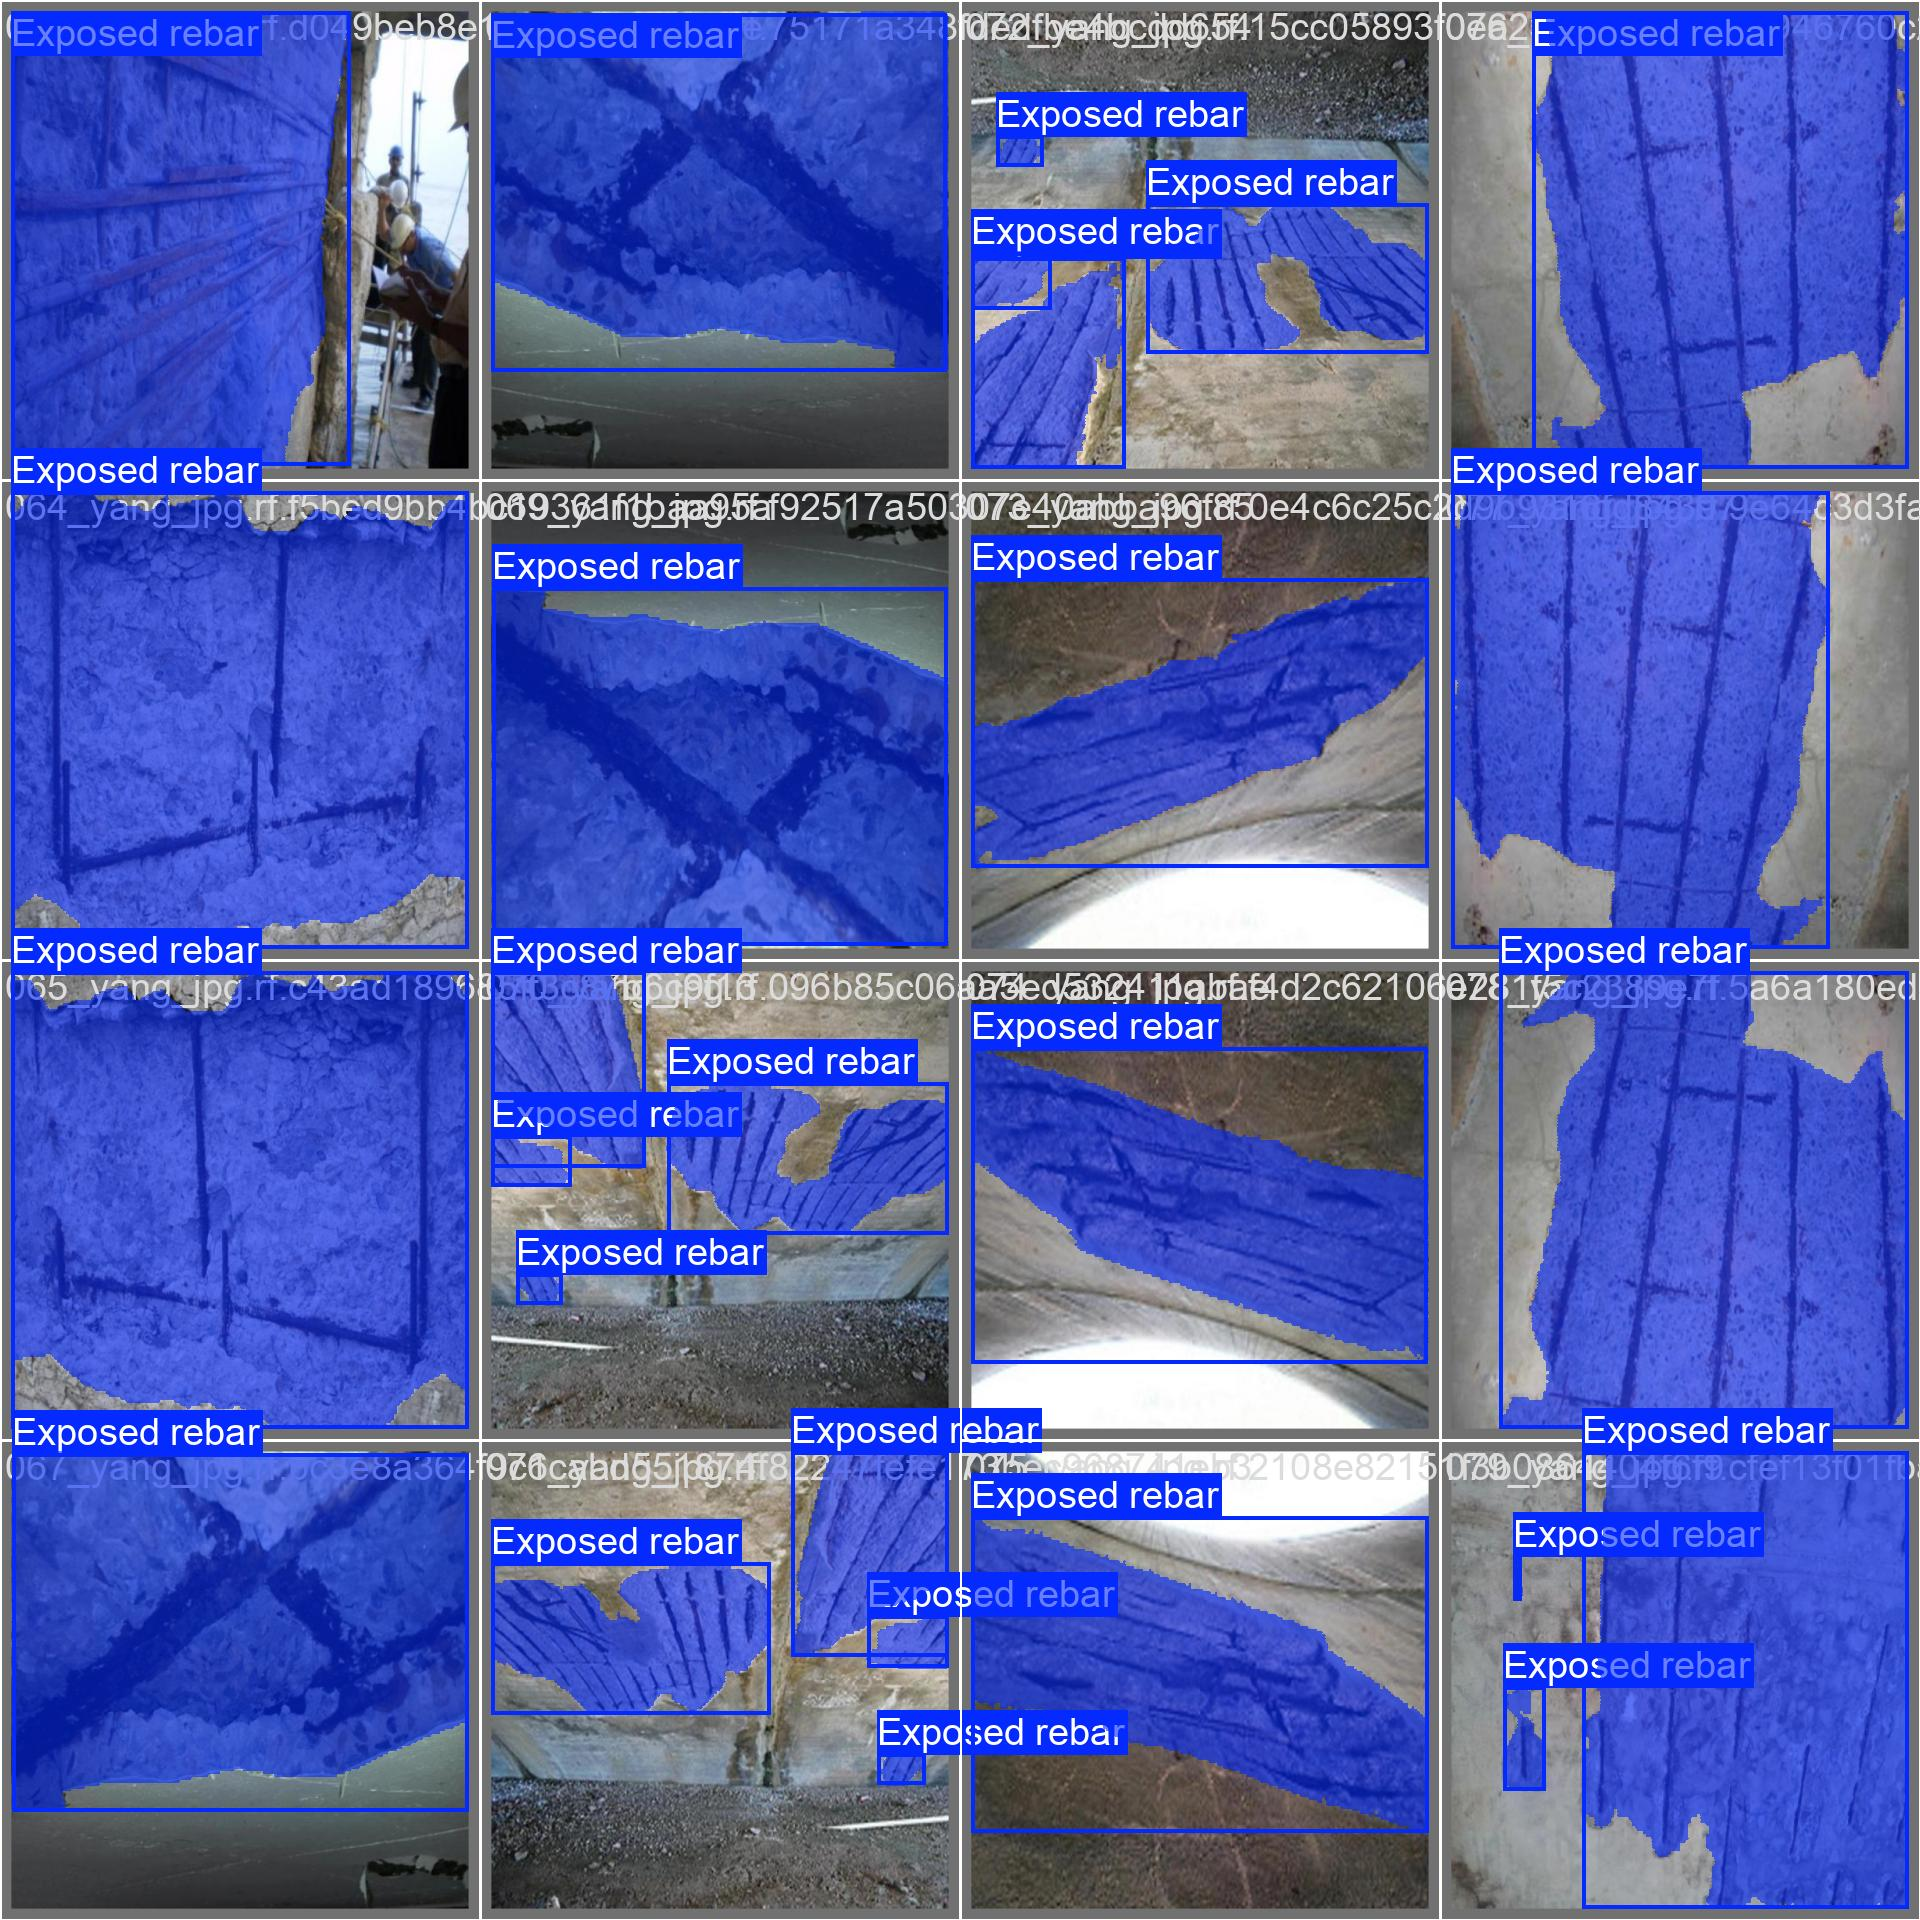

Model predictions


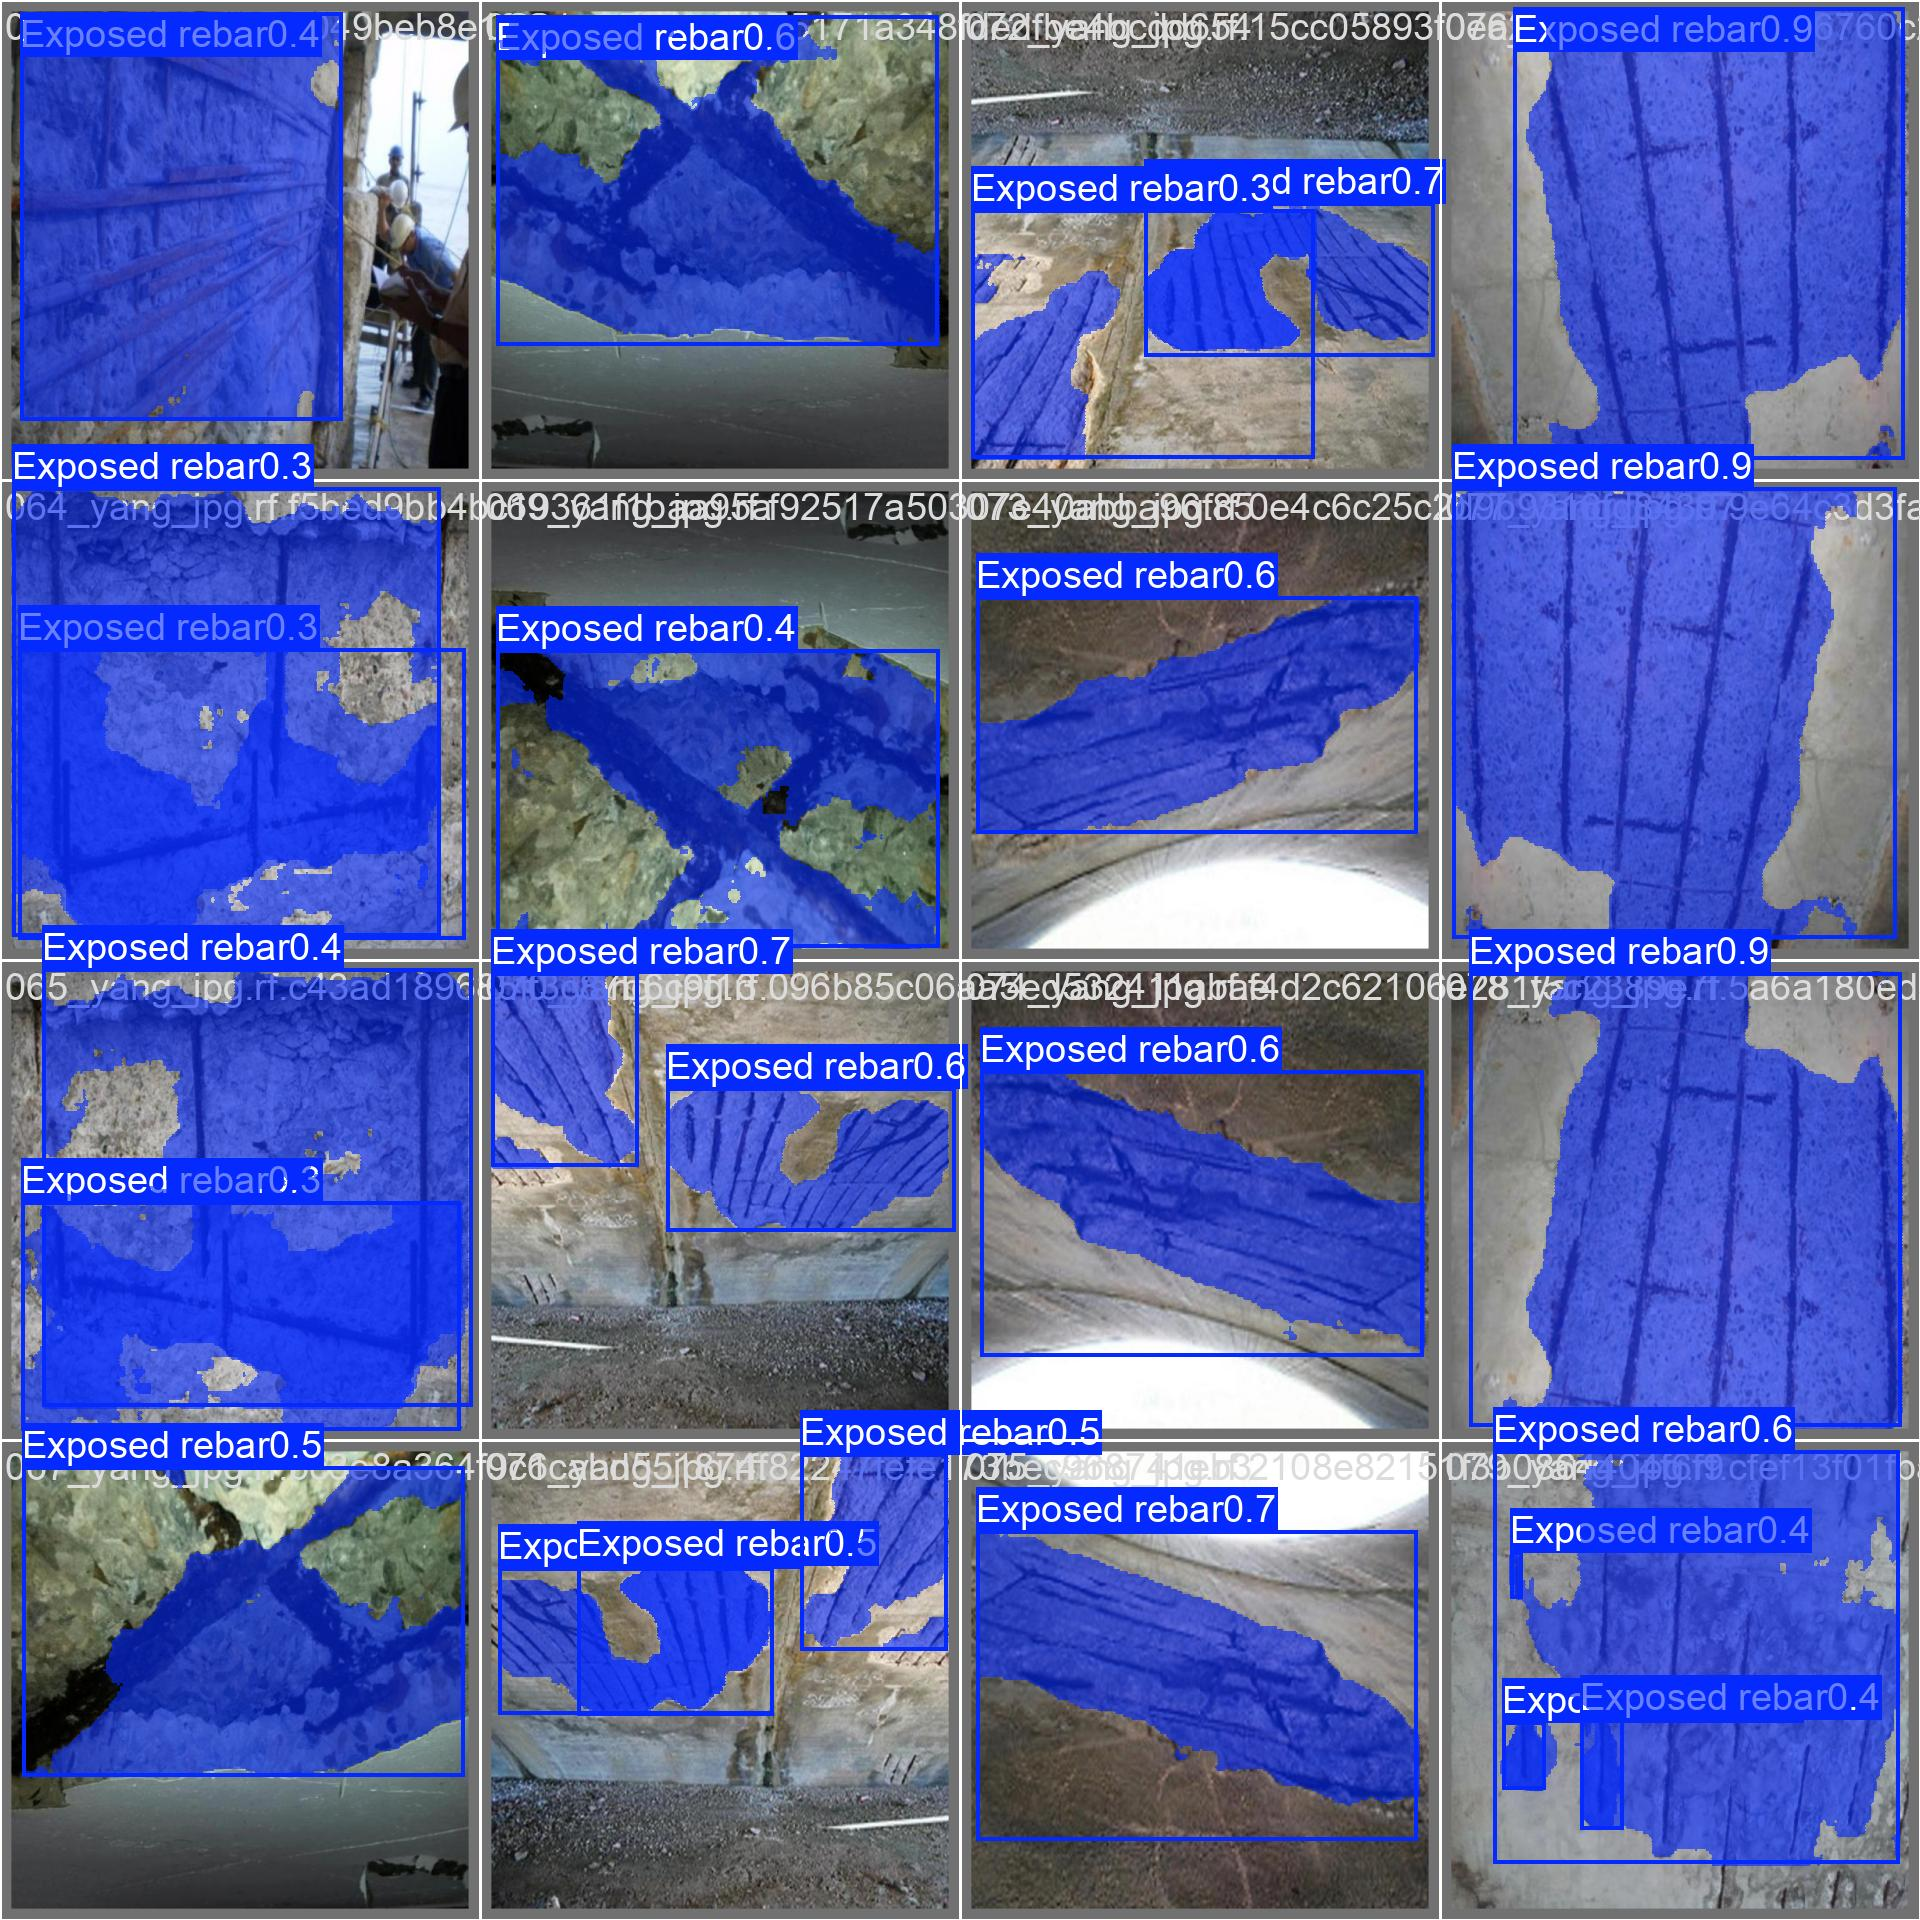

In [ ]:
from IPython.display import Image, display

print("Ground-truth labels")
display(Image(filename="/content/runs/exposed_rebar_verification/val_batch0_labels.jpg"))

print("Model predictions")
display(Image(filename="/content/runs/exposed_rebar_verification/val_batch0_pred.jpg"))

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")

results = model.train(
    data="/content/Rebar-exposure-4/data.yaml",
    epochs=30,
    imgsz=640,
    batch=8,
    device=0,
    project="/content/runs",
    name="exposed_rebar_30epochs",
    seed=42
)

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Rebar-exposure-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exposed_rebar_30epochs, nbs=64, nms=N

In [ ]:
!mkdir -p /content/evidence_final
!cp /content/runs/exposed_rebar_30epochs/results.png /content/evidence_final/
!cp /content/runs/exposed_rebar_30epochs/results.csv /content/evidence_final/
!cp /content/runs/exposed_rebar_30epochs/confusion_matrix.png /content/evidence_final/
!cp /content/runs/exposed_rebar_30epochs/confusion_matrix_normalized.png /content/evidence_final/
!cp /content/runs/exposed_rebar_30epochs/BoxPR_curve.png /content/evidence_final/
!cp /content/runs/exposed_rebar_30epochs/MaskPR_curve.png /content/evidence_final/
!cp /content/runs/exposed_rebar_30epochs/val_batch*_pred.jpg /content/evidence_final/
!cp /content/runs/exposed_rebar_30epochs/val_batch*_labels.jpg /content/evidence_final/
!cp /content/runs/exposed_rebar_30epochs/weights/best.pt /content/evidence_final/
!ls -lh /content/evidence_final

total 11M
-rw-r--r-- 1 root root 6.5M Sep 19 12:10 best.pt
-rw-r--r-- 1 root root  90K Sep 19 12:10 BoxPR_curve.png
-rw-r--r-- 1 root root 108K Sep 19 12:10 confusion_matrix_normalized.png
-rw-r--r-- 1 root root 109K Sep 19 12:10 confusion_matrix.png
-rw-r--r-- 1 root root  90K Sep 19 12:10 MaskPR_curve.png
-rw-r--r-- 1 root root 5.3K Sep 19 12:10 results.csv
-rw-r--r-- 1 root root 441K Sep 19 12:10 results.png
-rw-r--r-- 1 root root 596K Sep 19 12:10 val_batch0_labels.jpg
-rw-r--r-- 1 root root 606K Sep 19 12:10 val_batch0_pred.jpg
-rw-r--r-- 1 root root 577K Sep 19 12:10 val_batch1_labels.jpg
-rw-r--r-- 1 root root 610K Sep 19 12:10 val_batch1_pred.jpg
-rw-r--r-- 1 root root 675K Sep 19 12:10 val_batch2_labels.jpg
-rw-r--r-- 1 root root 700K Sep 19 12:10 val_batch2_pred.jpg


In [ ]:
!mkdir -p /content/new_images
!mkdir -p /content/new_predictions

In [ ]:
!ls -ld /content/new_images /content/new_predictions

drwxr-xr-x 2 root root 4096 Sep 19 12:10 /content/new_images
drwxr-xr-x 2 root root 4096 Sep 19 12:10 /content/new_predictions


In [ ]:
!mv /content/new_image_*.jpeg /content/new_images/
!ls -lh /content/new_images

total 2.0M
-rw-r--r-- 1 root root 411K Sep 19 12:57 new_image_1.jpeg
-rw-r--r-- 1 root root 237K Sep 19 12:56 new_image_2.jpeg
-rw-r--r-- 1 root root 154K Sep 19 12:57 new_image_3.jpeg
-rw-r--r-- 1 root root 225K Sep 19 12:56 new_image_4.jpeg
-rw-r--r-- 1 root root 154K Sep 19 12:56 new_image_5.jpeg
-rw-r--r-- 1 root root 179K Sep 19 12:57 new_image_6.jpeg
-rw-r--r-- 1 root root 181K Sep 19 12:57 new_image_7.jpeg
-rw-r--r-- 1 root root 207K Sep 19 12:57 new_image_8.jpeg
-rw-r--r-- 1 root root 206K Sep 19 12:57 new_image_9.jpeg


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/evidence_final/best.pt")

results = model.predict(
    source="/content/new_images",
    conf=0.25,
    save=True,
    project="/content",
    name="new_predictions",
    exist_ok=True
)


image 1/9 /content/new_images/new_image_1.jpeg: 640x480 (no detections), 7.8ms
image 2/9 /content/new_images/new_image_2.jpeg: 640x384 1 Exposed rebar, 52.6ms
image 3/9 /content/new_images/new_image_3.jpeg: 640x480 2 Exposed rebars, 9.7ms
image 4/9 /content/new_images/new_image_4.jpeg: 640x480 4 Exposed rebars, 8.4ms
image 5/9 /content/new_images/new_image_5.jpeg: 640x480 2 Exposed rebars, 8.5ms
image 6/9 /content/new_images/new_image_6.jpeg: 640x480 2 Exposed rebars, 8.3ms
image 7/9 /content/new_images/new_image_7.jpeg: 640x480 2 Exposed rebars, 8.6ms
image 8/9 /content/new_images/new_image_8.jpeg: 640x480 2 Exposed rebars, 8.7ms
image 9/9 /content/new_images/new_image_9.jpeg: 640x384 2 Exposed rebars, 9.0ms
Speed: 2.2ms preprocess, 13.5ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /content/new_predictions


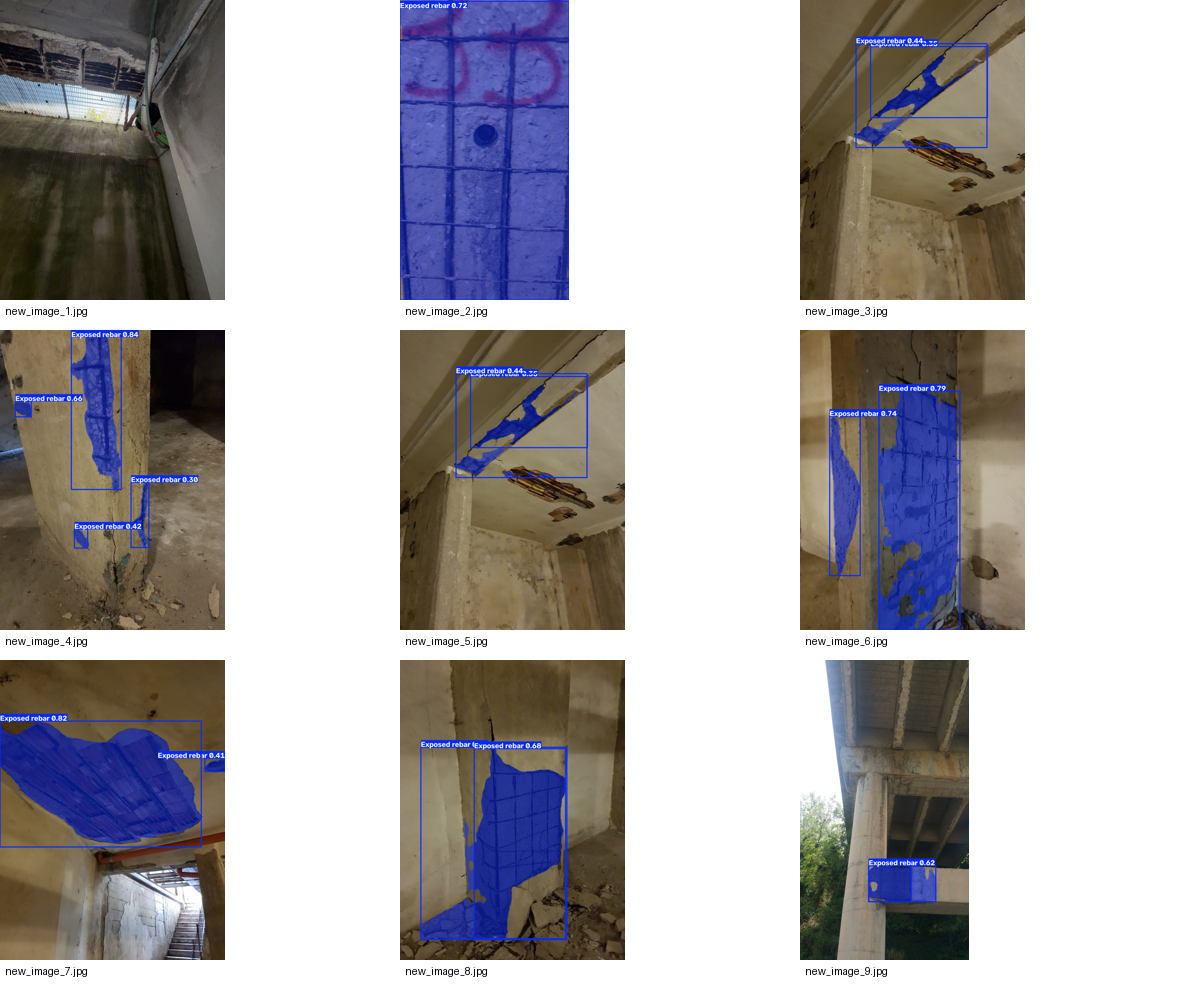

/content/new_predictions/contact_sheet.jpg


In [ ]:
from pathlib import Path
from PIL import Image, ImageDraw
import math

files = sorted(Path("/content/new_predictions").glob("*"))
images = [Image.open(f).convert("RGB") for f in files if f.suffix.lower() in {".jpg", ".jpeg", ".png"}]

thumb_width = 400
thumb_height = 300
cols = 3
rows = math.ceil(len(images) / cols)

sheet = Image.new("RGB", (cols * thumb_width, rows * (thumb_height + 30)), "white")
draw = ImageDraw.Draw(sheet)

for i, (image, file) in enumerate(zip(images, [f for f in files if f.suffix.lower() in {".jpg", ".jpeg", ".png"}])):
    image.thumbnail((thumb_width, thumb_height))
    x = (i % cols) * thumb_width
    y = (i // cols) * (thumb_height + 30)
    sheet.paste(image, (x, y))
    draw.text((x + 5, y + thumb_height + 5), file.name, fill="black")

sheet_path = "/content/new_predictions/contact_sheet.jpg"
sheet.save(sheet_path, quality=95)

display(sheet)
print(sheet_path)